# 6 — The controls: every knob, turned and measured

A result is only as good as the checks behind it. This notebook collects **every numerical
control of the campaign** in one place, so a reader of the thesis can see exactly what was
tested, how, and what came out. Each section states the question, names the thesis anchor and
the owning script, and then *runs* the analysis — every script below reads shipped caches in
`data/local/`, so this whole notebook executes in minutes.

| control | question | script |
|---|---|---|
| RTM vs RDM | does the truncation scheme change the answer? | `fig_conv.jl`, `battery_report.jl` |
| seed ensembles | how often does the iteration fail, and how spread are the survivors? | `battery_report.jl` |
| cutoff scan | does the SVD cutoff move the eigenvalues? | `battery_report.jl` |
| dense diagnostics | what does the exact (dense) operator say at small T? | `battery_report.jl` |
| Trotter step | does δt = 0.05 change anything but the cost? | `dtreport.jl` |
| bond dimension | χ = 64 against χ = 128 | `chi_check.jl` |
| warm vs cold starts | does warm-starting bias the answer? | `warmcold.jl` |
| eigen-mode agreement | do the :eig and :schur modes agree? | `mode_agreement.jl` |
| cost of compression | does capping the partial sums actually save time? | `costcheck.jl` |
| fit windows | how sensitive is c to the Eq. (3) window? | `eq3_windows.jl` |
| entropy fit models | which plateau extrapolation, and why? | `entropy_c.jl` |
| spectral seed statistics | does the block route fail near the wall? | `analysis_pack.jl` |

The scripts marked as *producers* in their headers (`spectral_seeds.jl`, `conv_history.jl`,
`warmcold.jl`, …) recompute physics only if their cache is deleted; run as-is they skip
straight to the tables.

In [1]:
# load the library: model Hamiltonians, the temporal-MPO construction, the block power
# method, the entropy routines, and the plotting theme
include("../src/thesislib.jl")
using JLD2, Printf, Statistics
thesis_plot_theme!()

## RTM against RDM: the convergence floor

Same rung, same seed, only the truncation scheme differs. RTM levels off above the tolerance
and stops on the no-improvement rule; RDM crosses it. The two eigenvalues agree to
$1.9\times10^{-6}$ — so the floor costs iterations, not accuracy. (Thesis: app. on failure
modes.)

rdm: converged, 74 iters, final change 8.34e-07, min 8.34e-07
rtm: stuck, 221 iters, final change 5.07e-06, min 2.45e-06


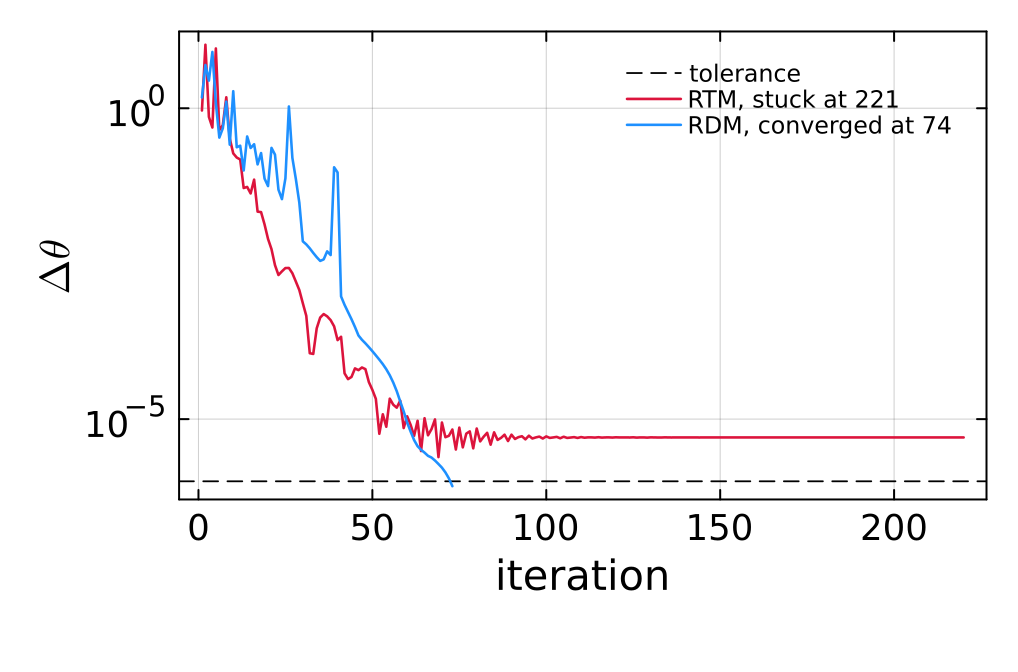

In [2]:
include("../scripts/figures/fig_conv.jl")
make_conv()

## Seed ensembles, the cutoff scan, and the dense diagnostics

The failure battery: every production rung repeated from independent random seeds (the spread
of the survivors is the honest error bar of the method), the SVD-cutoff scan, and the exact
diagnostics on the corrected column at small $T$. Add `detail` to the script's arguments for
the per-seed listing.

In [3]:
include("../scripts/analysis/battery_report.jl")

=== seed ensembles (single-vector route) ===
cache                      n    fail loose  fail tight  med(good)   spread     rigidity
seedens_dt005_p0.0_T18.0.jld2 20   1/20        1/20        0.1147     8.23e-03   1.03e-05


seedens_dt005_p0.0_T22.0.jld2 20   2/20        3/20        0.1043     2.86e-02   7.84e-07
seedens_dt005_p0.0_T24.0.jld2 20   6/20        10/20       0.0975     6.46e-02   2.12e-07
seedens_dt005_p0.1_T11.0.jld2 10   0/10        0/10        0.0970     7.15e-03   1.44e-08
seedens_dt005_p0.1_T12.0.jld2 10   2/10        5/10        0.0793     6.38e-02   2.68e-09
seedens_dt005_p0.3_T8.0.jld2 10   1/10        3/10        0.1372     2.75e-02   4.13e-07
seedens_dt005_p0.3_T9.0.jld2 10   4/10        6/10        0.1068     9.75e-02   6.03e-08
seedens_p0.0_T10.0.jld2    20   0/20        0/20        0.1209     1.27e-04   1.67e-03
seedens_p0.0_T12.0.jld2    20   0/20        0/20        0.1191     7.03e-04   4.60e-04
seedens_p0.0_T14.0.jld2    20   0/20        0/20        0.1186     1.45e-03   1.26e-04
seedens_p0.0_T16.0.jld2    20   0/20        0/20        0.1153     2.79e-03   3.47e-05
seedens_p0.0_T17.0.jld2    20   0/20        0/20        0.1137     1.22e-03   1.82e-05
seedens_p0.0_T18.0.jld2    

p     T     dim    |mu0|    |mu1/mu0|  gap01      rigidity   cond(V)    supp(trunc)
0.0   1.5   27     0.9048   0.92545    4.044e-01  4.327e-01  9.655e+00  1.08e-01


0.0   2.0   81     0.9129   0.95321    3.197e-01  3.145e-01  2.831e+01  3.62e-02
0.0   2.5   243    0.9153   0.96893    2.670e-01  2.291e-01  5.008e+01  1.04e-02
0.0   3.0   729    0.9173   0.97686    2.312e-01  1.640e-01  1.077e+02  2.35e-02
0.0   3.5   2187   0.9225   0.98257    2.053e-01  1.190e-01  2.991e+02  8.49e-03
0.1   1.0   169    0.9304   0.92539    4.561e-01  3.301e-01  1.914e+09  2.23e-02
0.1   1.5   2197   0.9405   0.96568    2.996e-01  1.625e-01  2.210e+11  1.05e-04
0.3   1.0   169    1.0347   0.96923    2.969e-01  3.377e-01  6.968e+08  4.53e-02
0.3   1.5   2197   1.1145   0.97494    1.853e-01  1.696e-01  2.089e+10  2.28e-02
0.5   1.0   169    1.2137   0.95528    2.023e-01  3.582e-01  2.079e+08  2.28e-02
0.5   1.5   2197   1.4391   0.96632    1.354e-01  1.949e-01  9.577e+09  1.14e-02

=== cutoff scan (block route, seeded) ===


p          T     cutoff    seed  niters  reason      time_s   g         plateau
0.0(fixed) 3.0   1e-12     1     17      converged   13       0.22814   0.0309


0.0(fixed) 3.0   1e-12     2     21      converged   18       0.22814   0.0309
0.0(fixed) 3.0   1e-12     3     18      converged   11       0.22814   0.0309
0.0(fixed) 3.0   1e-10     1     19      converged   14       0.22815   0.0306
0.0(fixed) 3.0   1e-10     2     25      converged   16       0.22815   0.0306
0.0(fixed) 3.0   1e-10     3     18      converged   11       0.22815   0.0306
0.0(fixed) 3.0   1e-08     1     51      converged   22       0.22815   0.0306
0.0(fixed) 3.0   1e-08     2     37      converged   19       0.22800   0.0244
0.0(fixed) 3.0   1e-08     3     51      converged   17       0.22815   0.0306
0.3        3.0   1e-12     1     48      converged   200      0.01406   0.1336
0.3        3.0   1e-12     2     67      converged   369      0.01406   0.1336
0.3        3.0   1e-12     3     55      converged   206      0.01406   0.1336
0.3        3.0   1e-10     1     57      converged   176      0.01406   0.1339
0.3        3.0   1e-10     2     221     stuck      

false

## The Trotter step

The same seed ensembles at $\delta t = 0.05$ against the $\delta t = 0.1$ baseline, plus the
three-step Trotter series of the plateau. The wall does not move and the observables barely
move — the production step is converged, and the finer step only doubles the temporal chain.

In [4]:
include("../scripts/analysis/dtreport.jl")

=== failure rate: dt=0.05 vs dt=0.1 baseline ===


p      T     dt=0.1         dt=0.05        med(good) dt=0.05
0.0    18    1/20           1/20           0.1147


0.0    22    2/20           2/20           0.1043
0.0    24    4/20           6/20           0.0975
0.1    11    2/10           0/10           0.0970
0.1    12    0/10           2/10           0.0793
0.3    8     4/10           1/10           0.1372
0.3    9     6/10           4/10           0.1068

=== plateau vs dt (Richardson check; dt=0.1 / 0.05 from earlier ladders) ===
p=0.0 T=12    dt=0.025: plateau=0.1154  (stuck@734, 144s)


## Bond dimension: χ = 64 against χ = 128

Both estimators (plateau and Re-slope), both couplings that have the doubled-χ ladders.

In [5]:
include("../scripts/analysis/chi_check.jl")


p=0  shared T: 

[8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0]
    T plat 64    plat 128   d%          c_Re 64    c_Re 128   diff     
    8 0.1252     0.1251     0.06        0.689      0.688      0.001    


   10 0.1213     0.1208     0.45        0.656      0.629      0.027    
   12 0.1183     0.1193     0.88        0.649      0.622      0.026    
   14 0.1202     0.1165     3.03        0.585      0.648      0.063    
   16 0.1173     0.1149     2.03        0.700      0.628      0.072    
   18 0.1117     0.1102     1.38        0.569      0.685      0.116    
   20 0.1162     0.1185     2.01        0.490      0.382      0.108    

p=0.1  shared T: [10.0, 11.0, 12.0]
    T plat 64    plat 128   d%          c_Re 64    c_Re 128   diff     
   10 0.1134     0.0228     79.89       0.668      -1.834     2.502    
   11 0.1257     0.1184     5.79        0.618      0.537      0.080    
   12 0.1521     0.1447     4.81        1.005      0.621      0.384    


## Block size: k = 4 against k = 6

The gap is a physical quantity, so it must not depend on how many states the block carries.
Running the same ladder with six states instead of four reproduces the four-state answer to about
$10^{-5}$ — except at three points, where the two disagree by a few per cent.

Those three are exactly where the $k=4$ ladder in notebook 3 jumps around. A four-state block is
cutting through the tower there rather than resolving it, which is why that panel is a qualitative
map of where the wall sits and why no number in the thesis is read off it.

In [6]:
# gap from a spectrum: lambda0 and its +/- partner are the two largest moduli, the gap is the next
function gap_of(theta)
    order = sortperm(abs.(theta), rev=true)
    rest = order[3:end]
    return isempty(rest) ? 0.0 : maximum(abs.(theta[rest])) / abs(theta[order[1]])
end

k4 = load("../data/local/nb55_pgap.jld2", "D")
k6 = load("../data/local/nb3_gap_k6.jld2", "done")

@printf("%-5s %-4s %-10s %-10s %-9s\n", "p", "T", "gap k=4", "gap k=6", "diff")
for key in sort([k for k in keys(k6) if k[1] == :k6], by = k -> (k[2], k[3]))
    p, T = key[2], key[3]
    g4, g6 = k4[p][T].gap, gap_of(k6[key].theta)
    @printf("%-5.1f %-4.0f %-10.4f %-10.4f %-9.1e\n", p, T, g4, g6, abs(g4 - g6))
end

p     T    gap k=4    gap k=6    diff     
0.0   2    0.6699     0.6699     4.6e-05  


0.0   3    0.8393     0.8393     2.9e-06  
0.0   4    0.9074     0.9074     5.0e-06  
0.0   5    0.9401     0.9401     4.2e-05  
0.0   6    0.9581     0.9581     6.5e-05  
0.0   7    0.9690     0.9690     4.4e-06  
0.1   2    0.7291     0.7292     2.9e-05  
0.1   3    0.8924     0.8924     1.2e-05  
0.1   4    0.9456     0.9456     1.7e-06  
0.1   5    0.9678     0.9678     7.6e-06  
0.1   6    0.9799     0.9787     1.2e-03  
0.3   2    0.8112     0.8113     6.0e-05  
0.3   3    0.9909     0.9514     3.9e-02  
0.3   4    0.8547     0.9482     9.4e-02  
0.5   2    0.8343     0.8343     8.8e-06  
0.5   3    0.8696     0.8696     1.4e-06  
0.5   4    0.9935     0.9002     9.3e-02  


## Warm against cold starts

Production ladders warm-start each rung from the previous block. Does that bias the answer?
Same rungs, same settings, same seed — only the initialisation differs.

In [7]:
include("../scripts/analysis/warmcold.jl")


=== warm versus cold at the same rungs ===


    T  cold (iters, s)        warm (iters, s)        d|mu0| relative
    3  68, 57                 68, 51                 0.00e+00


    4  234, 332               352, 471               6.82e-06
    5  409, 911               405, 851               6.77e-06
    6  352, 1249              416, 1494              1.16e-05


## Agreement of the two eigensolver modes

Two independent warm-started ladders at $p = 0.1$ on the corrected column, one per mode:
`:eig` (de-mixing, gives eigenvectors) against `:schur` (eigenvalue-only). Compared on the
Ritz-value ratios.

In [8]:
include("../scripts/analysis/mode_agreement.jl")


=== agreement of Ritz-value ratios between the two modes ===
   T  d|th1/th0|   d|th2/th0|   d|th3/th0|  
   2  8.50e-06     8.96e-04     3.38e-04    


   3  2.58e-06     1.96e-04     4.20e-03    
   4  2.76e-05     1.18e-02     6.28e-05    
   5  1.89e-06     3.64e-03     6.34e-04    
   6  4.92e-06     8.16e-05     1.01e-03    
   7  7.69e-08     1.39e-06     1.71e-03    
   8  1.72e-04     5.21e-04     2.47e-04    


## The cost of compressing the partial sums

The block update accumulates $k$ MPS; `accdim` caps the running direct sum. Claimed speed-ups
have to be measured: capped against plain at the same rungs, wall time and effect on
$|\mu_0|$.

In [9]:
include("../scripts/analysis/costcheck.jl")


=== compressing the partial sums: cost and effect on the answer ===


T=4  capped 234 its 316 s | plain 234 its 311 s | ratio 0.98 | d|mu0| 0.0e+00 relative
T=5  capped 262 its 635 s | plain 264 its 638 s | ratio 1.01 | d|mu0| 5.7e-07 relative


## Window sensitivity of the Eq. (3) fits

The spectral $c$ per coupling under every reasonable fit window, on the same ladders the
thesis quotes, plus the free-against-pinned branch constant.

In [10]:
include("../scripts/analysis/eq3_windows.jl")

p=0.0  ladder T=2.0..20.0 (30 pts)


  T>=2 (30 pts) | pinned c=0.4511 rms=4.1e-05 | free B/pi=-1.0004 c=0.4138
  T>=3 (28 pts) | pinned c=0.4707 rms=1.0e-05 | free B/pi=-1.0001 c=0.4542


  T>=4 (26 pts) | pinned c=0.4759 rms=7.9e-06 | free B/pi=-1.0001 c=0.4649
  window sensitivity of pinned c: spread 0.025
p=0.1  ladder T=2.0..9.5 (16 pts)
  T>=2 (16 pts) | pinned c=0.4663 rms=2.4e-05 | free B/pi=-1.0003 c=0.4306
  T>=3 (14 pts) | pinned c=0.4799 rms=6.5e-06 | free B/pi=-1.0002 c=0.4530
  T>=4 (12 pts) | pinned c=0.4862 rms=3.3e-06 | free B/pi=-1.0001 c=0.4662
  window sensitivity of pinned c: spread 0.020
p=0.3  ladder T=2.0..7.5 (12 pts)
  T>=2 (12 pts) | pinned c=0.4979 rms=3.8e-05 | free B/pi=-1.0004 c=0.4444
  T>=3 (10 pts) | pinned c=0.5151 rms=3.7e-05 | free B/pi=-1.0006 c=0.3873
  T>=4 ( 8 pts) | pinned c=0.5354 rms=4.0e-05 | free B/pi=-1.0017 c=0.1250
  window sensitivity of pinned c: spread 0.038
p=0.5  ladder T=2.0..6.0 (9 pts)
  T>=2 ( 9 pts) | pinned c=0.5332 rms=5.8e-05 | free B/pi=-1.0005 c=0.4466
  T>=3 ( 7 pts) | pinned c=0.5584 rms=6.2e-05 | free B/pi=-1.0016 c=0.1617
  T>=4 ( 5 pts) | pinned c=0.6221 rms=7.1e-05 | free B/pi=-1.0085 c=1.9204
  window

## The entropy-route fit models

The full entropy analysis: per-rung chord fits (uncorrected, corrected, pinned), the exact
$\beta_0$ regulator terms, and the AICc comparison of the plateau extrapolations — the
demonstrated reason the thesis quotes the CFT-predicted correction form and keeps the entropy
$c$ open.

In [11]:
include("../scripts/analysis/entropy_c.jl")


=== cluster p=0 (merged, round1 + unused bulk)  (clean to T=15.0, 24 of 27 rungs) ===


  T     plat4    c_unc    c_corr(se)       a_re     a_im     rmsP/F   
  2     0.1334   0.304    0.853  (0.201)    0.0091   0.0244   1.10    


  2.5   0.1418   0.751    1.452  (0.151)    -0.0167  0.0258   1.76    
  3     0.1314   0.785    1.372  (0.037)    -0.0241  0.0260   4.90    
  3.5   0.1286   0.721    1.006  (0.064)    -0.0521  0.0349   1.81    
  4     0.1300   0.648    0.919  (0.058)    -0.0573  0.0362   1.62    
  4.5   0.1323   0.687    0.896  (0.041)    -0.0597  0.0365   1.88    
  5     0.1287   0.680    0.844  (0.036)    -0.0613  0.0378   1.77    
  5.5   0.1302   0.634    0.732  (0.063)    -0.0677  0.0441   1.14    
  6     0.1289   0.647    0.657  (0.036)    -0.0746  0.0440   1.17    
  6.5   0.1266   0.786    0.608  (0.042)    -0.0775  0.0431   1.06    
  7     0.1227   0.751    0.631  (0.036)    -0.0803  0.0458   1.10    
  7.5   0.1248   0.693    0.549  (0.026)    -0.0796  0.0485   1.03    
  8     0.1243   0.731    0.603  (0.029)    -0.0815  0.0490   1.09    
  8.5   0.1231   0.683    0.525  (0.048)    -0.0835  0.0491   1.00    
  9     0.1241   0.660    0.540  (0.025)    -0.0816  0.0496   1.02    
  9.5 

    const         1      0.1253    4.40e-03  0.638
    a+b/sqrt(T)   2      0.1116    2.08e-03  0.568
    a+b/T         2      0.1194    2.46e-03  0.608
    a+b/T+c/T^2   3      0.1140    1.80e-03  0.581
    sqrtT model amplitude b=0.0354 -> implied a_im = b*sqrt(2/pi) = 0.0282

=== cluster p=0.1  (clean to T=9.5, 16 of 16 rungs) ===


  T     plat4    c_unc    c_corr(se)       a_re     a_im     rmsP/F   
  2     0.1335   0.882    2.059  (0.244)    -0.0261  0.0312   1.98    
  2.5   0.1335   0.788    1.756  (0.089)    -0.0412  0.0327   3.40    
  3     0.1332   0.594    1.300  (0.107)    -0.0468  0.0333   1.82    
  3.5   0.1345   0.588    0.699  (0.128)    -0.0776  0.0428   1.04    
  4     0.1344   0.705    0.695  (0.077)    -0.0763  0.0438   1.09    
  4.5   0.1338   0.733    0.619  (0.064)    -0.0756  0.0444   1.05    
  5     0.1314   0.717    0.565  (0.056)    -0.0780  0.0444   1.02    
  5.5   0.1288   0.741    0.288  (0.055)    -0.0841  0.0503   1.15    
  6     0.1285   0.682    0.315  (0.044)    -0.0848  0.0503   1.16    
  6.5   0.1273   0.684    0.358  (0.047)    -0.0841  0.0508   1.08    
  7     0.1307   0.721    0.463  (0.045)    -0.0879  0.0503   1.01    
  7.5   0.1289   0.608    0.379  (0.073)    -0.0796  0.0532   1.02    
  8     0.1287   0.590    0.404  (0.051)    -0.0823  0.0529   1.03    
  8.5



=== local p=0 chi64  (clean to T=29.0, 25 of 28 rungs) ===
  T     plat4    c_unc    c_corr(se)       a_re     a_im     rmsP/F   
  2     0.1284   0.622    1.479  (0.058)    -0.0022  0.0223   4.60    
  3     0.1316   0.704    1.255  (0.045)    -0.0229  0.0256   3.60    
  4     0.1318   0.694    0.884  (0.036)    -0.0538  0.0362   2.15    
  5     0.1298   0.714    0.834  (0.025)    -0.0598  0.0375   2.32    
  6     0.1273   0.735    0.736  (0.020)    -0.0730  0.0444   1.94    
  7     0.1274   0.718    0.682  (0.014)    -0.0750  0.0447   1.91    
  8     0.1252   0.681    0.636  (0.016)    -0.0796  0.0489   1.42    
  9     0.1219   0.674    0.596  (0.016)    -0.0795  0.0488   1.20    
  10    0.1213   0.671    0.621  (0.018)    -0.0842  0.0523   1.23    
  11    0.1217   0.685    0.609  (0.020)    -0.0823  0.0523   1.15    
  12    0.1183   0.641    0.597  (0.023)    -0.0847  0.0542   1.08    
  13    0.1229   0.611    0.523  (0.033)    -0.0808  0.0581   1.00    
  14    0.1202  

## Spectral seed statistics near the wall

The block (eigenvalue-only) route at $p = 0.3$, $T = 6, 6.5, 7$ — at and past the entropy
wall — from independent cold seeds, two lanes. Zero failures, phases to $\sim 10^{-4}$;
compare the 2/10 failures of the single-vector entropy route at the same coupling.

In [12]:
include("../scripts/analysis/analysis_pack.jl")

=== 1. the cooling regulator beta0: what changes when it moves ===
T     nbeta  beta0    |mu0|      plateau    corrected 
2     2      0.10     1.1590     0.1379     0.1473    


2     4      0.20     1.4963     0.1334     0.1529    
2     6      0.30     1.9315     0.1287     0.1591    
2     8      0.40     2.4928     0.1206     0.1618    
2     10     0.50     3.2163     0.1103     0.1617    
2     12     0.60     4.1491     0.0969     0.1568    
2     14     0.70     5.3518     0.0875     0.1578    
2     16     0.80     6.9011     0.0818     0.1668    
   -> spread across beta0: raw 50.0%, after dividing by (1-4beta0/piT) 12.3%

3     2      0.10     1.1563     0.1397     0.1459    
3     4      0.20     1.4922     0.1314     0.1436    
3     6      0.30     1.9253     0.1302     0.1492    
3     8      0.40     2.4841     0.1241     0.1495    
3     10     0.50     3.2047     0.1138     0.1444    
3     12     0.60     4.1340     0.1042     0.1398    
3     14     0.70     5.3322     0.0979     0.1392    
3     16     0.80     6.8773     0.0924     0.1399    
   -> spread across beta0: raw 40.5%, after dividing by (1-4beta0/piT) 7.1%

4     2      0.10   

p=0.1  13 rungs, k used [8], escalated at no rung
p=0.3  9 rungs, k used [8], escalated at no rung
p=0.5  6 rungs, k used [8], escalated at no rung

=== 3. spectral (block) seed ensemble at p=0.3 ===
T=6    6 seeds | |mu0| 1.702292..1.702348 (spread 3.3e-05) | arg/pi 0.0666..0.0667 | cluster 1.702342


T=6.5  6 seeds | |mu0| 1.702093..1.702254 (spread 9.5e-05) | arg/pi 0.3223..0.3224 | cluster 1.702423
T=7    6 seeds | |mu0| 1.701483..1.702479 (spread 5.9e-04) | arg/pi 0.5779..0.5782 | cluster 1.702835


## How to rerun any of this from scratch

Delete the corresponding cache under `data/local/` and run the producer script named in the
table; each is checkpointed and resumes if interrupted. The production cluster arms regenerate
through `cluster/` (see its README) — those are the only computations that need more than a
laptop.